# TCGA Mutation Frequency & Driver-Gene Labeling

This notebook:
1. Downloads somatic mutation (MAF) files from the GDC API for a set of TCGA cancer types
2. Computes per-gene mutation frequency across samples
3. Visualizes the mutation frequency distribution, overall and per cancer type
4. Builds a driver vs. non-driver gene label set, filtered by:
   - Known driver genes (COSMIC Cancer Gene Census)
   - Low mutation frequency in TCGA
   - Exclusion of genes in cancer-related Reactome pathways


## 1. Imports and Configuration

In [1]:
from pathlib import Path
import os
import random
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from collections import defaultdict
from typing import List, Tuple, Set

In [ ]:
DATA_DIR = Path("data/tcga_maf")
OUTPUT_DIR = Path("data")
OUTPUT_FILE = OUTPUT_DIR / "mutation_frequency_tcga.csv"

CANCER_TYPES = [
    "BRCA","LUAD","LUSC","HNSC",
    "KIRC","KIRP","PRAD","THCA",
    "STAD","ESCA","COAD","READ",
    "LIHC","UCEC","BLCA","CESC",
    "SKCM","OV","LAML","GBM",
    "LGG","SARC","PAAD","PCPG"
]


GDC_API_FILES = "https://api.gdc.cancer.gov/files"
GDC_API_DATA = "https://api.gdc.cancer.gov/data"

## 2. GDC Download Functions

Query the GDC API for MAF file IDs per project and download them locally. This version adds
request timeouts, HTTP status checks, and atomic writes (download to a `.tmp` file, then rename)
so a failed/interrupted download never leaves a corrupt MAF file behind.

In [9]:
def get_maf_file_ids(project: str, size: int = 200):
    params = {
        "filters": {
            "op": "and",
            "content": [
                {
                    "op": "in",
                    "content": {
                        "field": "cases.project.project_id",
                        "value": [f"TCGA-{project}"]
                    }
                },
                {
                    "op": "in",
                    "content": {
                        "field": "data_type",
                        "value": ["Masked Somatic Mutation"]
                    }
                }
            ]
        },
        "fields": "file_id,file_name",
        "format": "JSON",
        "size": size
    }

    response = requests.post(
        GDC_API_FILES,
        json=params,
        headers={"Content-Type": "application/json"},
        timeout=30
    )

    if response.status_code != 200:
        raise RuntimeError(f"GDC request failed: {response.status_code}")

    data = response.json()
    hits = data.get("data", {}).get("hits", [])

    return [(f["file_id"], f["file_name"]) for f in hits]

In [10]:
def download_maf_files(file_ids, project):
    project_dir = DATA_DIR / project
    project_dir.mkdir(parents=True, exist_ok=True)

    for file_id, file_name in file_ids:
        file_path = project_dir / file_name
        tmp_path = file_path.with_suffix(".tmp")

        if file_path.exists():
            print(f"[SKIP] {file_name}")
            continue

        url = f"{GDC_API_DATA}/{file_id}"
        print(f"[DOWNLOAD] {file_name}")

        try:
            r = requests.get(url, stream=True, timeout=60)

            if r.status_code != 200:
                print(f"[ERROR] Failed {file_id} ({r.status_code})")
                continue

            with open(tmp_path, "wb") as f:
                for chunk in r.iter_content(chunk_size=8192):
                    if chunk:
                        f.write(chunk)

            tmp_path.rename(file_path)

        except requests.exceptions.RequestException as e:
            print(f"[ERROR] {file_name}: {e}")
            if tmp_path.exists():
                tmp_path.unlink()

## 3. MAF Processing

Read each MAF file for a cancer type, keeping only the `Hugo_Symbol` and `Tumor_Sample_Barcode`
columns, and collect the set of unique (gene, sample) mutation pairs.

Note: unlike the earlier draft, this version does **not** filter by `Variant_Classification`
(functional vs. silent mutations) — every mutation record counts.

In [11]:
def process_maf(cancer_dir):
    gene_sample_pairs = set()
    sample_set = set()

    for maf_file in cancer_dir.rglob("*.maf*"):
        try:
            print(f"[PROCESS] {maf_file.name}")

            df = pd.read_csv(
                maf_file,
                sep="\t",
                comment="#",
                usecols=["Hugo_Symbol", "Tumor_Sample_Barcode"],
                dtype={"Hugo_Symbol": str, "Tumor_Sample_Barcode": str},
                compression="infer"
            )

            df = df.dropna().drop_duplicates()

            pairs = set(zip(df["Hugo_Symbol"], df["Tumor_Sample_Barcode"]))
            gene_sample_pairs.update(pairs)
            sample_set.update(df["Tumor_Sample_Barcode"])

        except Exception as e:
            print(f"[ERROR] {maf_file}: {e}")
            continue

    print(f"[SUMMARY] {len(gene_sample_pairs)} gene-sample pairs, {len(sample_set)} samples")

    return gene_sample_pairs, sample_set

## 4. Compute Mutation Frequency per Cancer Type

In [12]:
def compute_mutation_frequency(cancer, cancer_dir):
    gene_sample_pairs, sample_set = process_maf(cancer_dir)
    gene_counts = defaultdict(int)

    for gene, sample in gene_sample_pairs:
        gene_counts[gene] += 1

    num_samples = len(sample_set)
    results = []

    for gene, count in gene_counts.items():
        results.append({
            "gene": gene,
            "mutation_frequency": count / num_samples if num_samples > 0 else 0
        })

    return pd.DataFrame(results)

### Run the pipeline for all cancer types

This downloads MAF files for every project in `CANCER_TYPES`, computes mutation frequency for
each, and concatenates the results into a single CSV. Requires network access to the GDC API —
run this cell only when you're ready to fetch real data (it can take a while for 24 cancer
types).

In [13]:
all_df = []

for cancer in CANCER_TYPES:
    try:
        print(f"\n[PROCESSING] {cancer}")

        ids = get_maf_file_ids(cancer)
        print(f"[INFO] {len(ids)} files found")

        download_maf_files(ids, cancer)

        df = compute_mutation_frequency(cancer, DATA_DIR / cancer)

        if df is None or df.empty:
            print(f"[WARNING] No data for {cancer}")
            continue

        df["cancer_type"] = cancer

        print(f"[INFO] {cancer}: {df.shape}")
        all_df.append(df)

    except Exception as e:
        print(f"[ERROR] {cancer}: {e}")
        continue

# Final aggregation
if len(all_df) == 0:
    raise RuntimeError("No mutation data collected")

mutation_df = pd.concat(all_df, ignore_index=True)

mutation_df.to_csv(OUTPUT_FILE, index=False)

print("[DONE] Saved:", OUTPUT_FILE)
print(mutation_df.head())


[PROCESSING] BRCA
[INFO] 200 files found
[SKIP] e35fa380-07ac-45e1-9adc-4351675c6ccf.wxs.aliquot_ensemble_masked.maf.gz
[SKIP] ac3dbb7f-2ce9-43b7-9f45-1c1521e6bbf5.wxs.aliquot_ensemble_masked.maf.gz
[SKIP] a329335e-2962-485d-af32-1f6adf48cf7f.wxs.aliquot_ensemble_masked.maf.gz
[SKIP] fe1694df-4aca-4a23-bbf5-c0c1d24d4c2b.wxs.aliquot_ensemble_masked.maf.gz
[SKIP] c107d4de-6001-4027-a7f1-7c03d484ddaf.wxs.aliquot_ensemble_masked.maf.gz
[SKIP] 0b8a9b96-d855-482b-97bd-a45ff5a20468.wxs.aliquot_ensemble_masked.maf.gz
[SKIP] aa89b021-ab84-4c79-9624-e4831aa87df7.wxs.aliquot_ensemble_masked.maf.gz
[SKIP] f02cebd5-5840-4c63-bdf2-af7677e112e9.wxs.aliquot_ensemble_masked.maf.gz
[SKIP] 1f5ddd2c-04c3-4805-85fa-de57a9e5a76d.wxs.aliquot_ensemble_masked.maf.gz
[SKIP] 5c132854-804e-40cc-a6db-3252ebd928ef.wxs.aliquot_ensemble_masked.maf.gz
[SKIP] ef383034-1e77-4dc9-9283-357f7cb1549e.wxs.aliquot_ensemble_masked.maf.gz
[SKIP] ba72ca40-e70d-4d30-93fc-ac988b041d52.wxs.aliquot_ensemble_masked.maf.gz
[SKIP] ed6

## 5. Explore Mutation Frequency Results

Load the saved CSV and visualize the distribution of mutation frequencies, both overall and
broken down by cancer type, plus the top mutated genes per cancer type.

In [14]:
df = pd.read_csv("data/mutation_frequency_tcga.csv")
df.head()

,gene,mutation_frequency,cancer_type
0,CLINT1,0.002747,BRCA
1,DENND1B,0.010989,BRCA
2,RAPGEF2,0.013736,BRCA
3,NF1,0.046703,BRCA
4,SELP,0.013736,BRCA


### 5.1 Overall mutation frequency distribution (log scale)

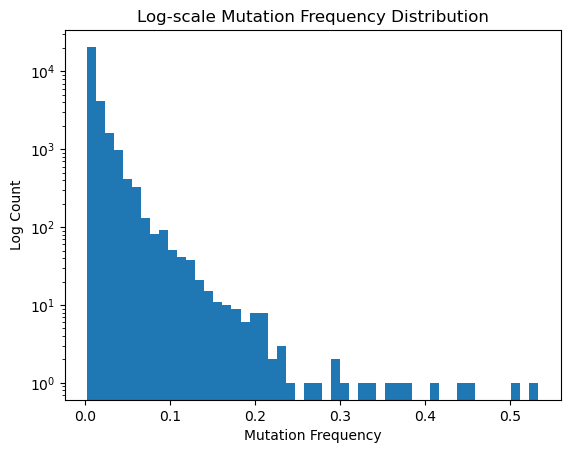

In [15]:
plt.figure()
plt.hist(df["mutation_frequency"] + 1e-6, bins=50)
plt.yscale("log")
plt.xlabel("Mutation Frequency")
plt.ylabel("Log Count")
plt.title("Log-scale Mutation Frequency Distribution")
plt.show()

### 5.2 Mutation frequency distribution per cancer type (overlaid)

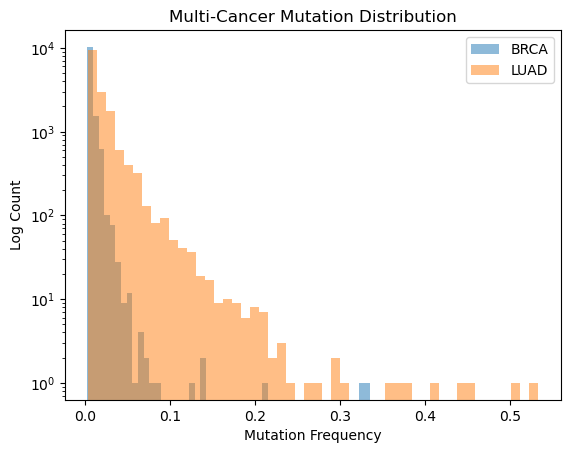

In [16]:
if "cancer_type" in df.columns:
    cancers = df["cancer_type"].unique()

    plt.figure()
    for cancer in cancers:
        subset = df[df["cancer_type"] == cancer]["mutation_frequency"]
        plt.hist(subset + 1e-6, bins=50, alpha=0.5, label=cancer)

    plt.yscale("log")
    plt.xlabel("Mutation Frequency")
    plt.ylabel("Log Count")
    plt.title("Multi-Cancer Mutation Distribution")
    plt.legend()
    plt.show()
else:
    print("No cancer_type column found.")

### 5.3 Top 10 most frequently mutated genes, per cancer type

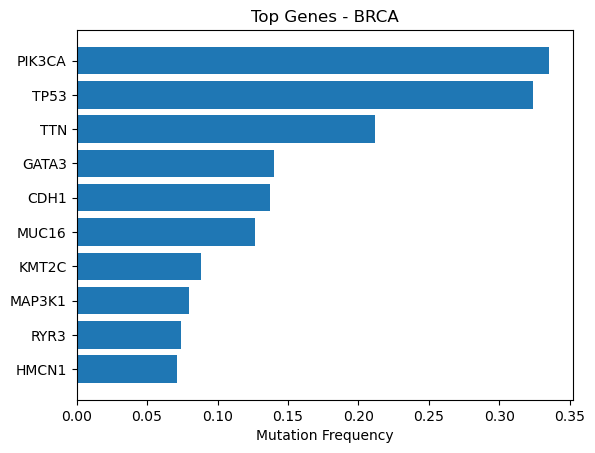

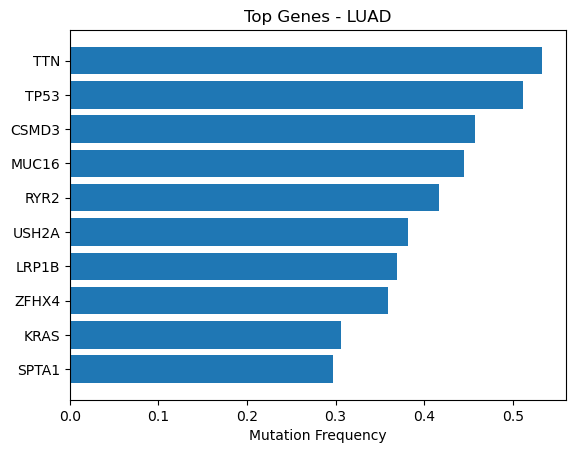

In [17]:
if "cancer_type" in df.columns:
    for cancer in df["cancer_type"].unique():
        sub = df[df["cancer_type"] == cancer]
        top = sub.sort_values("mutation_frequency", ascending=False).head(10)

        plt.figure()
        plt.barh(top["gene"], top["mutation_frequency"])
        plt.gca().invert_yaxis()
        plt.title(f"Top Genes - {cancer}")
        plt.xlabel("Mutation Frequency")
        plt.show()
else:
    print("No cancer_type column found.")

## 6. Driver vs. Non-Driver Gene Labeling Pipeline

Builds the gene universe from GENCODE, identifies known driver genes from COSMIC's Cancer Gene Census,
and filters candidate non-driver genes by mutation frequency (using the CSV produced above) and
cancer pathway membership.

In [18]:
USE_MUTATION_FILTER = True
USE_PATHWAY_FILTER = True
USE_DEGREE_MATCH = True
RANDOM_SEED = 42

random.seed(RANDOM_SEED)

### 6.1 Build the gene universe from GENCODE annotation

In [19]:
gtf_file = "../data/gencode.v49.basic.annotation.gtf"

genes = set()

with open(gtf_file, "r") as f:
    for line in f:
        if line.startswith("#"):
            continue

        fields = line.strip().split("\t")

        # Keep only gene entries
        if len(fields) < 9 or fields[2] != "gene":
            continue

        info = fields[8]

        # Extract gene_name safely
        gene_name = None
        for item in info.split(";"):
            item = item.strip()
            if item.startswith("gene_name"):
                gene_name = item.split('"')[1]
                break

        if gene_name:
            genes.add(gene_name)

# Save gene universe
gencode_df = pd.DataFrame(sorted(genes), columns=["gene_name"])
gencode_df.to_csv("data/gencode_genes.csv", index=False)

print(f"\u2705 GENCODE genes: {len(genes)}")

✅ GENCODE genes: 77078


### 6.2 Load driver genes (COSMIC Cancer Gene Census) and compute raw non-drivers

In [20]:
all_genes = set(pd.read_csv("data/gencode_genes.csv")["gene_name"])

cgc = pd.read_csv("../data/Census_allWed.tsv", sep="\t")
driver_genes = set(cgc["Symbol"].dropna())

print(f"Driver genes: {len(driver_genes)}")

non_drivers = all_genes - driver_genes
print(f"Raw non-drivers: {len(non_drivers)}")

Driver genes: 763
Raw non-drivers: 76331


### 6.3 Apply mutation-frequency filter

Remove non-driver candidates with mutation frequency ≥ 1% in TCGA.

In [21]:
if USE_MUTATION_FILTER:
    mutation_df = pd.read_csv("../data/mutation_frequency_tcga.csv")

    low_mut_genes = set(
        mutation_df[mutation_df["mutation_frequency"] < 0.01]["gene"]
    )

    before = len(non_drivers)
    non_drivers = non_drivers & low_mut_genes
    print(f"After mutation filter: {len(non_drivers)} (-{before - len(non_drivers)})")

After mutation filter: 13540 (-62791)


### 6.4 Build cancer pathway gene set from Reactome

In [22]:
reactome_file = "../data/reactome/ReactomePathways.gmt"

genes = set()

with open(reactome_file) as f:
    for line in f:
        parts = line.strip().split("\t")
        pathway_genes = parts[2:]  # skip pathway name + description
        genes.update(pathway_genes)

df_pathway = pd.DataFrame(sorted(genes), columns=["gene"])
df_pathway.to_csv("data/cancer_pathway_genes.csv", index=False)

print(f"Saved {len(genes)} pathway genes")

Saved 11939 pathway genes


### 6.5 Apply pathway filter

Exclude non-driver candidates that belong to any cancer-related Reactome pathway.

In [23]:
# if USE_PATHWAY_FILTER:
pathway_df = pd.read_csv("data/cancer_pathway_genes.csv")

cancer_pathway_genes = set(pathway_df["gene"])

before = len(non_drivers)
non_drivers = non_drivers - cancer_pathway_genes
print(f"After pathway filter: {len(non_drivers)} (-{before - len(non_drivers)})")

After pathway filter: 5263 (-8277)


### 6.6 Build and save the labeled gene table

In [24]:
labels = []

for g in driver_genes:
    labels.append((g, 1))

for g in non_drivers:
    labels.append((g, 0))

labels_df = pd.DataFrame(labels, columns=["gene", "label"])

print(labels_df["label"].value_counts())

output_path = "data/processed/gene_labels_driver_vs_nondriver.csv"
os.makedirs("data/processed", exist_ok=True)
labels_df.to_csv(output_path, index=False)

print(f"\u2705 Saved \u2192 {output_path}")

label
0    5263
1     763
Name: count, dtype: int64
✅ Saved → data/processed/gene_labels_driver_vs_nondriver.csv


### 6.7 Save driver / non-driver gene lists as plain text files

In [25]:
driver_path = os.path.join("data/processed", "driver_genes.txt")
with open(driver_path, "w") as f:
    for gene in driver_genes:
        f.write(f"{gene}\n")

nondriver_path = os.path.join("data/processed", "non_driver_genes.txt")
with open(nondriver_path, "w") as f:
    for gene in non_drivers:
        f.write(f"{gene}\n")

print(f"\u2705 Saved driver genes \u2192 {driver_path}")
print(f"\u2705 Saved non-driver genes \u2192 {nondriver_path}")

✅ Saved driver genes → data/processed/driver_genes.txt
✅ Saved non-driver genes → data/processed/non_driver_genes.txt
